# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [35]:
import pandas as pd

game_chat_df = pd.read_csv('data\game_chat.csv')

In [36]:
game_chat_df.head()

,match_id,radiant_chat,dire_chat
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх
1,102127,NaN,NaN
2,383046,u just buy levels blue? | fa ge,NaN
3,729879,NaN,NaN
4,126886,NaN,NaN


In [37]:
game_chat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700838 entries, 0 to 700837
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   match_id      700838 non-null  int64
 1   radiant_chat  90624 non-null   str  
 2   dire_chat     90604 non-null   str  
dtypes: int64(1), str(2)
memory usage: 16.0 MB


Наш датафрейм устроен так, что в каждой строке у каждой команды выписаны все сообщения через |

Так же у нас очень много значений NaN

Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:**

- Для токенизации объединю сообщения каждой команды каждого матча в единый текст и использую `RegexpTokenizer` из `nltk.tokenize`, так как это позволит осатвить только слова, что будет полезно для лемматизации, а так же уберёт шум знаков препинания
- Для того, чтобы леммитизация отработала хорошо, приведу все слова к нижнему регистру и удалю повторы символов
- Заменю все занчения NaN на пустую строку для удобства дальнейшей обработку
- Посколькку в моём датасете есть слова на разных языках: на русском и на английском, я буду использовать `mysteam` (так как pymorfy2 ломается на моём питоне) для обработки русских слов и `WordNetLemmatizer`из `nltk.stem` для остальных языков.


</div>

In [38]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to C:\Users\Asya-
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Asya-
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [39]:
import re
import inspect
from collections import namedtuple
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
import pymorphy2

#костыль, чтобы pymorfy2 заработал на моём питончике
ArgSpec = namedtuple('ArgSpec', 'args varargs keywords defaults')

def getargspec(func):
    spec = inspect.getfullargspec(func)
    return ArgSpec(spec.args, spec.varargs, spec.varkw, spec.defaults)

inspect.getargspec = getargspec

tokenizer = RegexpTokenizer(r'\w+')
morph = pymorphy2.MorphAnalyzer()
eng_lemmatizer = WordNetLemmatizer()


def remove_repeated_chars(word):
    return re.sub(r'(.)\1{2,}', r'\1\1', word)


def lemmatize_word(word):
    if re.search(r'[а-яё]', word):
        return morph.parse(word)[0].normal_form
    
    if re.search(r'[a-z]', word):
        return eng_lemmatizer.lemmatize(word)
    
    return word


def preprocessing(text: str):
    if pd.isna(text):
        return ''
    
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    tokens = [remove_repeated_chars(token) for token in tokens]
    tokens = [lemmatize_word(token) for token in tokens]
    
    return ' '.join(tokens)

In [40]:
# можете проверить, что делает ваша функция, на тесте ниже
print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

ляя ваш мама такой красивый ну вылитый пуджа 0


In [41]:
game_chat_df['radiant_chat_prep'] = game_chat_df['radiant_chat'].apply(preprocessing)
game_chat_df['dire_chat_prep'] = game_chat_df['dire_chat'].apply(preprocessing)

In [42]:
game_chat_df.head()

,match_id,radiant_chat,dire_chat,radiant_chat_prep,dire_chat_prep
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх,потренироваться с бот,саппорт u lagging brah stack шлюха
1,102127,NaN,NaN,,
2,383046,u just buy levels blue? | fa ge,NaN,u just buy level blue fa ge,
3,729879,NaN,NaN,,
4,126886,NaN,NaN,,


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [43]:
from scipy.sparse import load_npz

heroes_matrix = load_npz("heroes_matrix.npz")

In [44]:
matches_df_copy = pd.read_pickle("matches_df_copy.pkl")

In [45]:
chat_df = game_chat_df[game_chat_df['match_id'].isin(matches_df_copy['match_id'])].copy()
chat_df = chat_df.sort_values('match_id').reset_index(drop=True)

chat_df['radiant_chat_prep'] = chat_df['radiant_chat'].apply(preprocessing)
chat_df['dire_chat_prep'] = chat_df['dire_chat'].apply(preprocessing)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

tfidf_radiant = TfidfVectorizer(max_features=5000, min_df=5)
tfidf_dire = TfidfVectorizer(max_features=5000, min_df=5)

X_radiant = tfidf_radiant.fit_transform(chat_df['radiant_chat_prep'])
X_dire = tfidf_dire.fit_transform(chat_df['dire_chat_prep'])

regions = [col for col in matches_df_copy.columns if col.startswith('region')]
with_sqrt_mmr = regions + ['sqrt_mmr', 'is_missing']
X_numeric = matches_df_copy[with_sqrt_mmr]

X_all = hstack([csr_matrix(X_numeric), heroes_matrix, X_radiant, X_dire])

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


y = matches_df_copy['radiant_win']

X_train, X_val, y_train, y_val = train_test_split(X_all, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
gini = 2 * auc - 1

print("ROC-AUC:", auc)
print("Gini:", gini)

ROC-AUC: 0.657905616523133
Gini: 0.3158112330462659


Gini действительно увеличился, это радует

#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

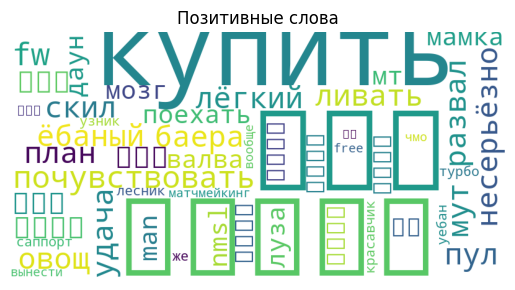

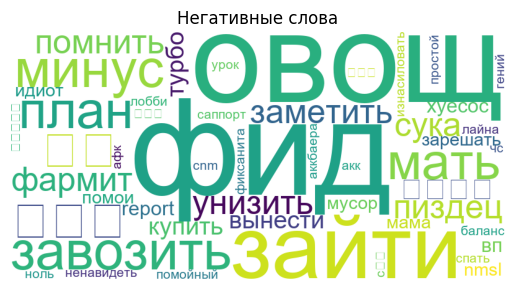

In [75]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

words = list(tfidf_radiant.get_feature_names_out()) + list(tfidf_dire.get_feature_names_out())
start_text = X_numeric.shape[1] + heroes_matrix.shape[1]
weights = model.coef_[0][start_text:start_text + len(words)]
idx = np.argsort(weights)
top_negative = {words[i]: abs(weights[i]) for i in idx[:50]}
top_positive = {words[i]: weights[i] for i in idx[-50:]}

wc = WordCloud(width=800, height=400, background_color="white")
wc.generate_from_frequencies(top_positive)
plt.imshow(wc)
plt.axis("off")
plt.title("Позитивные слова")
plt.show()

wc = WordCloud(width=800, height=400, background_color="white", font_path="C:/Windows/Fonts/arial.ttf")
wc.generate_from_frequencies(top_negative)
plt.imshow(wc)
plt.axis("off")
plt.title("Негативные слова")
plt.show()

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:**

Да, довольно негативненько получилось...

Много оскорблений и резких слов, и как раз такие эмоциональные слова несут сигнал о том, что кто-то проигрывает или выигрывает

Интересно, что в среднем негативные слова крупнее, то есть они больше влияют на модель. В этом есть какой-то смысл: наверно, когда команда проигрывает, игроки начинают активнее переписываться, договариваться или оскорблять друг друга

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [2]:
import pandas as pd

dota_adv = pd.read_csv('data\dota_adv.csv')

In [3]:
dota_adv.head()

,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]


In [5]:
dota_adv.info()

<class 'pandas.DataFrame'>
RangeIndex: 767822 entries, 0 to 767821
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          767822 non-null  int64
 1   radiant_gold_adv  767822 non-null  str  
 2   radiant_exp_adv   767822 non-null  str  
dtypes: int64(1), str(2)
memory usage: 17.6 MB


In [9]:
#сейчас значения строки, преобразуем их в массив

import numpy as np

def parse(x):
    x = x.strip('[]')
    if x == '':
        return []
    return np.array(list(map(int, x.split())))

dota_adv['gold_adv'] = dota_adv['radiant_gold_adv'].apply(parse)
dota_adv['exp_adv'] = dota_adv['radiant_exp_adv'].apply(parse)

In [13]:
dota_adv['gold_adv'][5]

array([    0,  -248,  -527, -1054, -1387, -1808, -1808, -1613, -1290,
       -1290, -1290, -2001, -2001, -2001, -3389, -5279])

Посмотрим, все ли массивы состоят из 0 или из 16 элементов (c 0 минуты)

In [14]:
dota_adv['gold_adv'].apply(len).value_counts()

gold_adv
0     529783
16    238039
Name: count, dtype: int64

In [15]:
dota_adv['exp_adv'].apply(len).value_counts()

exp_adv
0     529783
16    238039
Name: count, dtype: int64

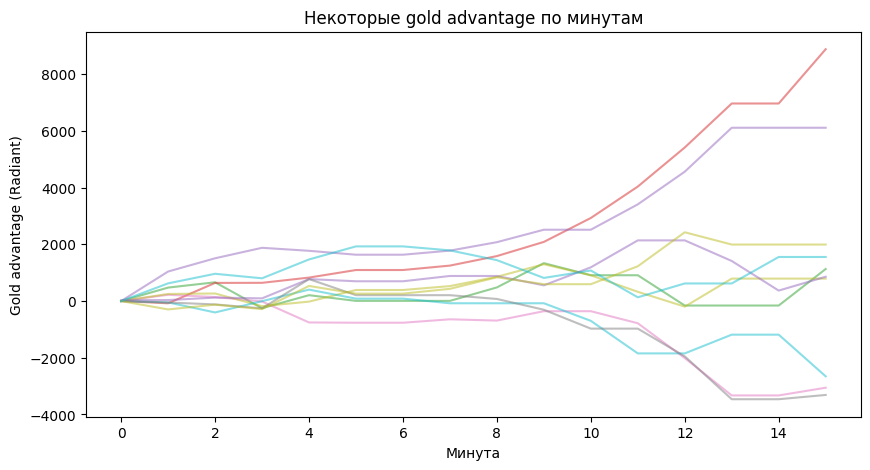

In [19]:
import random

plt.figure(figsize=(10,5))

sample_matches = dota_adv['gold_adv'].sample(20)

for adv in sample_matches:
    plt.plot(adv, alpha=0.5)

plt.title("Некоторые gold advantage по минутам")
plt.xlabel("Минута")
plt.ylabel("Gold advantage (Radiant)")
plt.show()

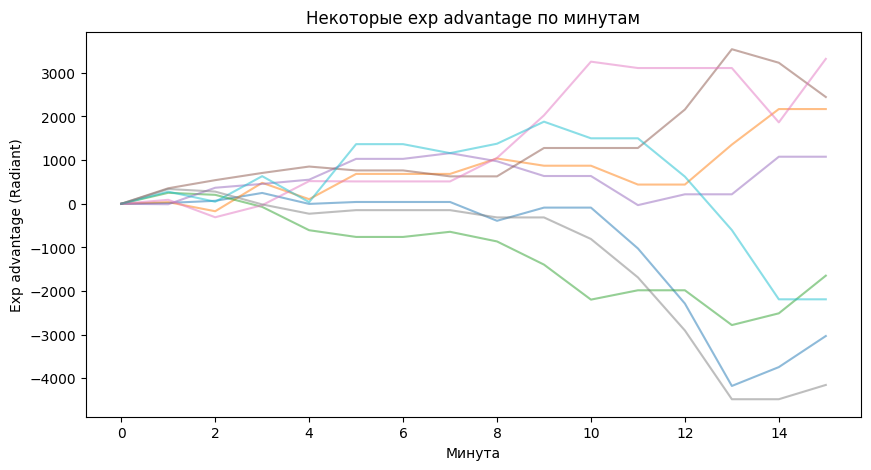

In [27]:
import random

plt.figure(figsize=(10,5))

sample_matches = dota_adv['exp_adv'].sample(20)

for adv in sample_matches:
    plt.plot(adv, alpha=0.5)

plt.title("Некоторые exp advantage по минутам")
plt.xlabel("Минута")
plt.ylabel("Exp advantage (Radiant)")
plt.show()

Видим, что в начале у всех advantage плюс минус одинаковый, а к концу уже сильно расходится, то есть advantage на последних минутах несёт сильный сигнал

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:**

1) `mean` - среднее значение advantage
2) `last3_mean` - среднее значение advantage на последних 3х минутах, так как на граыиках мы увидели, что там будут сильные расхождения
3) `std` - стабильность игры, признак будет полезен вместе с остальными, по сути он показывает, насколько значениям можно доверять
4) `q80` - 80 квантиль, который покажет высокое значение advantage, достигнутое во время игры

При этом есть строки, где массив перимуществ пустой, надо бы статистические значения в этих строках чем-то заполнить. Наверно можно запонить медианными значениями этих агрегаций.

</div>

In [29]:
dota_adv['gold_mean'] = dota_adv['gold_adv'].apply(lambda x: np.mean(x) if len(x)>0 else np.nan)
dota_adv['exp_mean'] = dota_adv['exp_adv'].apply(lambda x: np.mean(x) if len(x)>0 else np.nan)

dota_adv['gold_last3_mean'] = dota_adv['gold_adv'].apply(lambda x: np.mean(x[-3:]) if len(x)>0 else np.nan)
dota_adv['exp_last3_mean'] = dota_adv['exp_adv'].apply(lambda x: np.mean(x[-3:]) if len(x)>0 else np.nan)

dota_adv['gold_std'] = dota_adv['gold_adv'].apply(lambda x: np.std(x) if len(x)>0 else np.nan)
dota_adv['exp_std'] = dota_adv['exp_adv'].apply(lambda x: np.std(x) if len(x)>0 else np.nan)

dota_adv['gold_q80'] = dota_adv['gold_adv'].apply(lambda x: np.quantile(x,0.8) if len(x)>0 else np.nan)
dota_adv['exp_q80'] = dota_adv['exp_adv'].apply(lambda x: np.quantile(x,0.8) if len(x)>0 else np.nan)

cols = ['gold_mean','exp_mean', 'gold_last3_mean', 'exp_last3_mean', 'gold_std','exp_std', 'gold_q80','exp_q80']
for c in cols:
    dota_adv[c] = dota_adv[c].fillna(dota_adv[c].median())

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [60]:
matches_df_copy.head()

,match_id,date,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10,game_mode,duration,radiant_win,avg_mmr,is_missing,sqrt_mmr
0,1,2024-02-12,1,0,0,0,0,0,0,0,0,0,4,2625,False,3519.70,0,59.327060
1,2,2024-04-08,0,1,0,0,0,0,0,0,0,0,2,7526,True,2330.90,0,48.279395
2,3,2024-06-16,0,0,1,0,0,0,0,0,0,0,1,2831,True,1579.60,0,39.744182
3,4,2024-09-16,0,0,0,1,0,0,0,0,0,0,22,1438,False,2846.85,1,53.355881
4,5,2024-03-31,0,1,0,0,0,0,0,0,0,0,22,2051,True,2846.85,1,53.355881


In [51]:
adv_df = dota_adv[dota_adv['match_id'].isin(matches_df_copy['match_id'])].copy()
adv_df = adv_df.sort_values('match_id').reset_index(drop=True)

adv_df = dota_adv[dota_adv['match_id'].isin(matches_df_copy['match_id'])].copy()
adv_df = adv_df.sort_values('match_id').reset_index(drop=True)

adv_features = adv_df[[
    'gold_mean', 'exp_mean',
    'gold_last3_mean', 'exp_last3_mean',
    'gold_std', 'exp_std',
    'gold_q80', 'exp_q80'
]]

X_all = hstack([csr_matrix(X_numeric), heroes_matrix, csr_matrix(adv_features)])

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

y = matches_df_copy['radiant_win']

X_train, X_val, y_train, y_val = train_test_split(X_all, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
gini = 2 * auc - 1

print("ROC-AUC:", auc)
print("Gini:", gini)

ROC-AUC: 0.6934760187378974
Gini: 0.3869520374757949


c:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Оо отличненько, джини увеличился даже по сравнению с предыдущей частью

In [66]:
from scipy.sparse import load_npz

heroes_matrix_test = load_npz("heroes_matrix_test.npz")
data_test = pd.read_pickle('data_test.pkl')

In [67]:
adv_df_test = dota_adv[dota_adv['match_id'].isin(data_test['match_id'])].copy()
adv_df_test = adv_df_test.sort_values('match_id').reset_index(drop=True)

adv_features_test = adv_df_test[[
    'gold_mean', 'exp_mean',
    'gold_last3_mean', 'exp_last3_mean',
    'gold_std', 'exp_std',
    'gold_q80', 'exp_q80'
]]

X_numeric_test = data_test[with_sqrt_mmr]

In [56]:
X_all_test = hstack([csr_matrix(X_numeric_test), heroes_matrix_test, csr_matrix(adv_features_test)])

pred = model.predict_proba(X_all_test)[:, 1]

submission = pd.DataFrame({
    "ID": X_all_test["match_id"],
    "Value": pred
})

submission.to_csv("submission.csv", index=False)

KeyError: "['region_1', 'region_2', 'region_3', 'region_4', 'region_5', 'region_6', 'region_7', 'region_8', 'region_9', 'region_10', 'is_missing'] not in index"

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [ ]:
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str]):
        self.columns = columns

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        raise Exception("transform method not implemented")

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.